# Quasi-Monte Carlo

In [25]:
import math
import numpy as np
from numpy.random import default_rng
rng = default_rng()

from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

Le principe d’une méthode Quasi-Monte Carlo est de remplacer les nombres
pseudo-aléatoires $(U_k)_{k \ge 1}$ par une suite déterministe
$(\xi_k)_{k \ge 1}$ qui remplit *mieux* l’espace $[0,1]^d$. On mesure la
qualité de répartition d’une suite dans $[0,1]^d$ par la notion de
discrépance.

Supposons $X$ une variable aléatoire à valeurs dans
$E \subset \mathbf{R}^d$. Supposons qu’il existe $\Psi: [0,1]^q \to E$
telle que $X \sim \Psi(U)$ où $U \sim \mathcal{U}([0,1]^q)$. Par exemple
si on note la fonction de répartition $F_X(x) = \mathbf{P}[X \le x]$ et
$F_X^{-1}$ l’inverse généralisée de $F_X$ (connue sous le nom de
fonction quantile) alors $X \sim F_X^{-1}(U)$ où
$U \sim \mathcal{U}([0,1])$ (ici $q = 1$).

Avec cette représentation de $X$ on a 

$$
    \mathbf{E}\big[\varphi(X)\big] = \mathbf{E}\big[ \varphi\big(\Psi(U)\big) \big] = \lim_{n \to +\infty} \frac{1}{n} \sum_{k=1}^n \varphi\big(\Psi(\xi_k)\big),
$$

où $(\xi_k)_{k \ge 1}$ est une suite à discrépance faible (Halton ou
Sobol) sur $[0,1]^q$. Si $\varphi \circ \Psi$ est à variation finie on a
le résultat de Koksma-Hlawka pour contrôler l’erreur mais en pratique
cette inégalité est difficilement appplicable car on ne connait pas la
variation finie $V(\varphi \circ \Psi)$.

> **Warning**
>
> La suite $(\xi_k)_{k \ge 1}$ n’est pas une suite de nombres
> pseudo-aléatoires car on ne demande pas la propriété d’indépendence de
> $\xi_{k+1}$ par rapport à $\xi_k$ (et plus généralement
> $\sigma(\xi_j, j \le k)$). Ne pas faire un code où l’on remplace
> naïvement les appels de $U_k$ par $\xi_k$.
>
> Par exemple si vous simulez un coupe de Gaussiennes indépendantes par
> la méthode de Box-Muller à partir d’un couple $(U_{2k}, U_{2k+1})$
> **vous ne devez pas** remplacer ce couple par
> $(\xi_{2k}, \xi_{2k+1})$. Il faut augmenter la dimension de la suite
> $(\xi_k)_{k \ge 1}$

## Koksma-Hlawka

Soit $(\xi_n)_{n \ge 1}$ une suite sur $[0,1]^d$ et $f$ à variation
$V(f)$ finie. Alors où $D_n^*(\xi)$ est la discrépance de la suite
$(\xi_n)_{n \ge 1}$ définie par

Une méthode de Quasi-Monte Carlo est similaire à une méthode de Monte
Carlo où les nombres pseudo-aléatoires sont remplacés par des suites
dites à *discrépance faible*, c’est à dire dont la discrépance vérifie:

> **Important**
>
> Si $(U_n)_{n \ge 1}$ est une suite *i.i.d.* uniformément distribuée
> sur $[0,1]^d$, alors (par la loi du logarithme itéré) La discrépance
> est donc de l’ordre de $\sqrt{\log(\log(n))} / \sqrt{2n}$.

> **Note**
>
> La borne déterminisite donnée par le résultat de Koksma-Hlawka permet
> de donner un intervalle de confiance mais il faut connaitre la
> variation $V(f)$ de la fonction et même en connaissant cette quantité
> l’intervalle est beaucoup trop grand par rapport aux observations
> empiriques. D’autre part une méthode fonctionne même lorsque la
> fonction est à variation infinie $V(f) = +\infty$.
>
> Dans le cas d’une méthode “randomisée” Random Quasi-Monte Carlo on
> peut répliquer $K$ fois l’estimateur ($K$ petit, par exemple 10) et
> déduire un intervalle de confiance empirique (cf. section 3 sur les
> options basket).

## Suites à discrépance faible

### Suite de Van der Corput $(d = 1)$

La suite de Van der Corput repose sur la manipulation des coefficients
de la décomposition $p-$adique de $n \ge 1$:

-   Soit $p$ un nombre premier qui sert de base à la décomposition
    $p-$adique
-   Décomposition de $n$:
-   Construction de $\xi^{(p)}_n$ appelée dans la suite VdC en base
    $p$:  

**Discrépance:**

**Important**
Montrer que

$$
    \lim_{n \to \infty} \frac{1}{n} \sum_{k=1}^n \xi^{(2)}_{2k} \xi^{(2)}_{2k+1} = \frac{5}{24}
$$ 

alors que si $(U_n)_{n \ge 1}$ suite *i.i.d.* uniforme sur $(0,1)$

$$
    \lim_{n \to \infty} \frac{1}{n} \sum_{k=1}^n U_{2k} U_{2k+1} = \frac{1}{4}.
$$

#### Implémentation naïve

L’idée la plus simple consiste à décomposer $n$ en base $p$ pour obtenir
les coefficients $a_0, \dots, a_r$ puis de construire $\xi_n^{(p)}$.

> **Note**
>
> Voici un code que l’on peut obtenir sur le site
> [rosettacode.org](https://rosettacode.org/wiki/Van_der_Corput_sequence#Python).
> Ce site est utile et instructif pour trouver des algorithmes
> correctement écrits dans plusieurs langages de programmation.

In [26]:
def vdc(n, p=2):
    xi_n, denom = 0, 1
    while n:
        denom *= p
        n, remainder = divmod(n, p)
        xi_n += remainder / denom
    return xi_n

Si on veut construire les $n = 100\,000$ premières itérations, on itère
les appels de la fonction `vdc`. Cela ne semble pas optimal et en effet
le temps d’exécution moyen est **très lent**.

In [27]:
n = int(1e6)
print(f"Temps d'exécution pour {n} itérations:")
%timeit np.array([vdc(i, p=2) for i in range(n)])
%timeit np.array([vdc(i, p=11) for i in range(n)])
print(f"Pour comparaison, un échantillon de {n} nombres pseudo-aléatoires:")
%timeit rng.random(n)

Temps d'exécution pour 1000000 itérations:
1.11 s ± 12.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
407 ms ± 3.88 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Pour comparaison, un échantillon de 1000000 nombres pseudo-aléatoires:
2.29 ms ± 26.1 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


#### Représentation des premiers points pour différentes bases

On affiche les premières itérations de la suite de VdC pour les
premières bases $p=2, 3, 5, 7$. La construction montre une certaine
régularité, visible lorsque $p$ augmente.

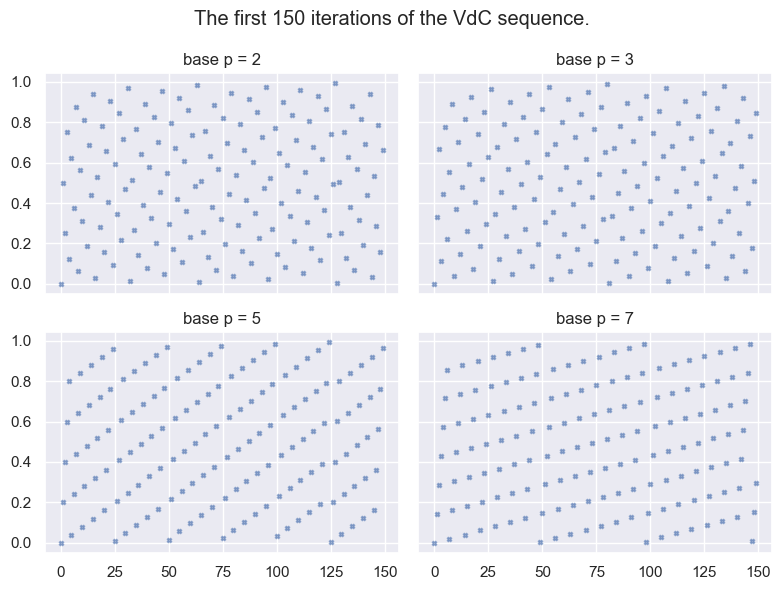

In [28]:
n = 150
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(8, 6), 
                        sharex=True, sharey=True, layout='tight')
for ax, p in zip(axs.flat, [2, 3, 5, 7]): 
    xi_n = [ vdc(k, p=p) for k in range(n) ]
    ax.scatter(np.arange(n), xi_n, s=10, marker='X', alpha=0.5)
    ax.set_title(f"base p = {p}")
fig.suptitle(f"The first {n} iterations of the VdC sequence.")
plt.show()

#### Implémentation améliorée en `numpy`

L’idée est de construire directement une plage d’itérations de la suite
$(\xi^{(p)}_n)_{n \ge 0}$. On note $[r]_p$ le vecteur des $p^r$
premières itérations et $\xi^{(p)_{[r]_p}}$ les éléments de la suite de
Van der Corput associée 

$$
    [r]_p = \big(0, 1, \dots, p^r-1) \quad \text{et}  \quad 
    \xi^{(p)}_{[r]_p} = \big( \xi^{(p)}_0, \xi^{(p)}_1, \dots, \xi^{(p)}_{p^r-1} \big)
$$

**Note**

La construction du vecteur à $p^{r+1}$ éléments $[r+1]_{p}$ se fait à
partir du vecteur $[r]_p$ en posant: 

$$
   [r+1]_{p} = \big( [r]_p \;,\; [r]_p + p^r \;,\; [r]_p + 2p^r \;,\; \dots \;,\; [r]_p + (p-1) p^r \big)
$$ 
(la concaténation de $p$ vecteurs de taille $p^r$).

En `numpy` on peut utiliser le broadcasting pour construire
efficacement $[r+1]_{p}$ à partir de $[r]_{p}$. On a $[1]_{p}$ qui
correspond à `np.arange(p)` et voici comment construire $[2]_p$ puis
$[3]_p$
>
> ``` python
> p = 3
> coeffs = np.arange(p).reshape(-1, 1)
> u1 = coeffs.flatten()
> print(u1)
> u2 = (u1 + coeffs * p).flatten()
> print(u2)
> u3 = (u2 + coeffs * p**2).flatten()
> print(u3)
> ```
>
>     [0 1 2]
>     [0 1 2 3 4 5 6 7 8]
>     [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
>      24 25 26]

De la même façon on peut construire les $p^{r+1}$ premières itérations
de la suite de VdC à partir d’une transformation simple des $p^r$
premières itérations. Plus préciseement on a 

$$
  \xi^{(p)}_{[r+1]_p} = \Big( \xi^{(p)}_{[r]_p} \;,\; \xi^{(p)}_{[r]_p} + \frac{1}{p^{r+1}} \;,\; \dots \;,\; \xi^{(p)}_{[r]_p} + \frac{p-1}{p^{r+1}} \Big)
$$

In [29]:
def van_der_corput_r(r: int, p: int):
    """ Produce the Van der Corput sequence from 0 to p**r-1. """
    coeffs = np.arange(p).reshape(-1, 1)
    seq = (coeffs / p).reshape(-1)
    for k in range(2, r+1):
        seq = (seq + coeffs / p**k).reshape(-1)
    return seq

van_der_corput_r(r=3, p=2) 

array([0.   , 0.5  , 0.25 , 0.75 , 0.125, 0.625, 0.375, 0.875])

On écrit alors une fonction `van_der_corput` qui génère la suite jusqu’à
l’itération $n$ donnée. Il suffit de déterminer $r$ tel que
$p^{r-1}\le n < p^{r}$.

In [30]:
def van_der_corput(n: int, p: int):
    """ Produce the Van der Corput sequence from 0 to n. """
    r = math.ceil(math.log(n) / math.log(p))
    seq = van_der_corput_r(r, p)
    return seq[:n]

Avec cette implémentation purement `numpy` et non `python` on obtient
des temps du même ordre de grandeur que les nombres pseudos-aléatoires
(générés en interne en `C++`).

In [31]:
n = int(1e6)
%timeit van_der_corput(n, p=2)
%timeit van_der_corput(n, p=11)

3.39 ms ± 31.2 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
3.09 ms ± 24.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


### Suite de Halton

Soit $d$ la dimension, et $p_1,\dots, p_d$ les $d$ premiers nombres
premiers.

La suite de Halton en dimension $d \ge 2$ est définie à partir des
suites de Van der Corput dans les différentes bases $p_1, \dots, p_d$

**Discrépance:**

In [32]:
def halton(n: int = 10, d: int = 2):
    """ Halton sequence in dimension d from 0 to n. """
    """ Warning: only for d < 25"""
    primes = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 
              43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89, 97]
    result = [ van_der_corput(n, primes[k]) for k in range(d) ]
    return np.array(result).T

In [33]:
halton(n=7, d=5)

array([[0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.5       , 0.33333333, 0.2       , 0.14285714, 0.09090909],
       [0.25      , 0.66666667, 0.4       , 0.28571429, 0.18181818],
       [0.75      , 0.11111111, 0.6       , 0.42857143, 0.27272727],
       [0.125     , 0.44444444, 0.8       , 0.57142857, 0.36363636],
       [0.625     , 0.77777778, 0.04      , 0.71428571, 0.45454545],
       [0.375     , 0.22222222, 0.24      , 0.85714286, 0.54545455]])

#### Représentation graphique

Attention pour la suite de Halton ainsi construite on a un effet
indésirable qui apparaît lorsque la dimension augmente.

In [34]:
sample = halton(n = 1000, d=20)     # faire avec n = 5000...

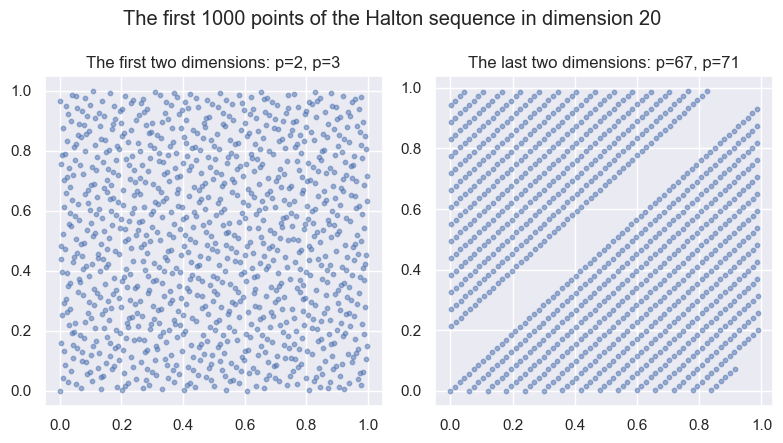

In [35]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(8, 4.5), layout='tight')
ax1.scatter(sample[:,0], sample[:,1], s=10, marker='o', alpha=0.5)
ax1.set_title("The first two dimensions: p=2, p=3")
ax2.scatter(sample[:,-2], sample[:,-1], s=10, marker='o', alpha=0.5) 
ax2.set_title("The last two dimensions: p=67, p=71")
fig.suptitle("The first 1000 points of the Halton sequence in dimension 20")
plt.show()

#### Utilisation de `scipy`

Dans le sous-module `qmc` du module `stats` de `scipy` vous trouvez de
nombreux algorithmes pour le Quasi-Monte Carlo. En particulier il y a
une classe `Halton` pour générer une suite de `Halton`. Le constructeur
demande la dimension du problème `d`. Lorsque l’objet est créé, la
méthode `random` prend un argument `n` et renvoie les `n` prochaines
valeurs de la suite de Halton.

Pour plus d’information il faut consulter la page d’aide:
`?stats.qmc.Halton`.

In [36]:
halt = stats.qmc.Halton(d=5, scramble=False) 
# on discute de l'option `scramble` dans la section suivante
halt.random(n = 7)

array([[0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.5       , 0.33333333, 0.2       , 0.14285714, 0.09090909],
       [0.25      , 0.66666667, 0.4       , 0.28571429, 0.18181818],
       [0.75      , 0.11111111, 0.6       , 0.42857143, 0.27272727],
       [0.125     , 0.44444444, 0.8       , 0.57142857, 0.36363636],
       [0.625     , 0.77777778, 0.04      , 0.71428571, 0.45454545],
       [0.375     , 0.22222222, 0.24      , 0.85714286, 0.54545455]])

> **Warning**
>
> Le nom de la méthode `random` est très mal choisi: ce n’est pas
> aléatoire, mais on comprend que cet appel renvoie les `n=7` premières
> itérations de la suite, avec modification de l’état interne. Si on
> appel de nouveau la méthode `random` sur l’objet `halt` on obtient les
> itérations suivantes.

> **Note**
>
> On peut vérifier que les 2 algorithmes déterministes (le notre et
> celui de `scipy`) construisent la même suite par exemple en calculant
> l’erreur $\ell^1$ totale (qui ne contient que la somme des erreurs
> d’arrondies):
>
> ``` python
> halt = stats.qmc.Halton(d=5, scramble=False)
> n = int(1e6)
> np.sum(np.abs(halt.random(n) - halton(n, d=5)))
> ```
>
>     5.3544276098166554e-11

#### Perturbation

Pour atténuer l’effet de ligne en grande dimension qui est du à la trop
grande régularité dans la construction des suites de Van der Corput on
peut “agiter” un peu cette construction. Plus précisément on perturbe la
construction en considérant une permutation des coefficients
apparaissant dans la décomposition p-adique.

L’algorithme de perturbation implémenté via l’option `scramble` est issu
de l’article [A randomized Halton algorithm in
R](https://arxiv.org/pdf/1706.02808.pdf).

In [37]:
halt = stats.qmc.Halton(d=20, scramble=True)
sample = halt.random(n=1000)

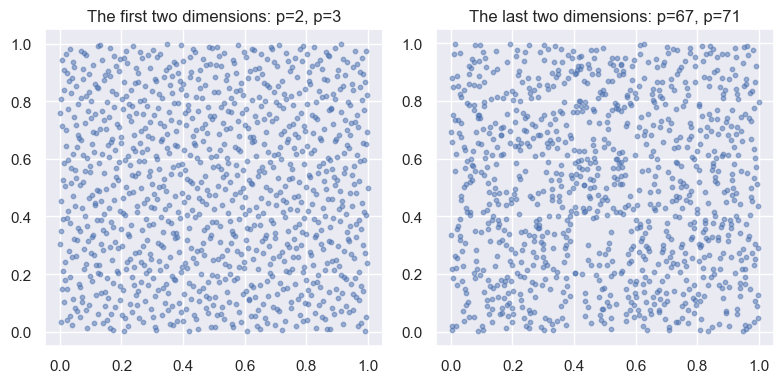

In [38]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(8, 4), layout='tight')
ax1.scatter(sample[:,0], sample[:,1], s=10, marker='o', alpha=0.5)
ax1.set_title("The first two dimensions: p=2, p=3")
ax2.scatter(sample[:,-2], sample[:,-1], s=10, marker='o', alpha=0.5) 
ax2.set_title("The last two dimensions: p=67, p=71")
plt.show()

#### Retour sur Van der Corput et on l’agite!

On revient sur le code précédent et on applique cette idée de
permutation des coefficients. Dans notre approche, cela se fait en
utilisant la fonction `rng.shuffle` qui applique une permutation
aléatoire aux coefficients `coeffs`.

In [39]:
def van_der_corput_r(r: int, p: int, scramble: bool=True):
    """ Produce the Van der Corput sequence from 0 to p**r-1 (with scramble option). """
    coeffs = np.arange(p)[np.newaxis]
    if scramble: 
        rng.shuffle(coeffs, axis=1)
    seq = coeffs / p
    for k in range(2, r+1):
        if scramble: 
            rng.shuffle(coeffs, axis=1)
        seq = (seq + coeffs.T/p**k).reshape((1, -1))
    seq = seq.flatten()
    return seq

def van_der_corput(n: int, p: int, scramble: bool=True):
    """ Produce the Van der Corput sequence from 0 to n (with scramble option). """
    r = math.ceil(math.log(n) / math.log(p))
    seq = van_der_corput_r(r, p, scramble)
    return seq[:n]

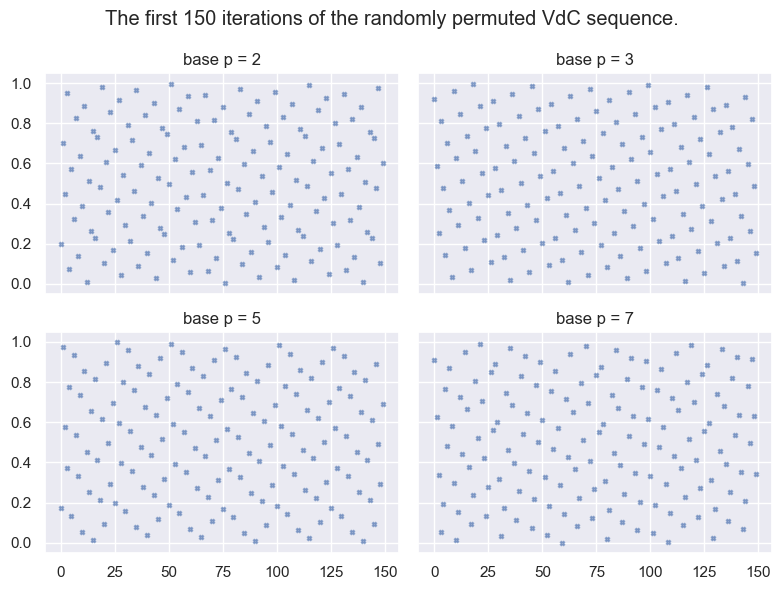

In [40]:
n = 150
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(8, 6), 
                        sharex=True, sharey=True, layout='tight')
for ax, p in zip(axs.flat, [2, 3, 5, 7]): 
    xi_n = van_der_corput(n, p)
    ax.scatter(np.arange(n), xi_n, s=10, marker='X', alpha=0.5)
    ax.set_title(f"base p = {p}")
fig.suptitle(f"The first {n} iterations of the randomly permuted VdC sequence.")
plt.show()

In [41]:
sample = halton(n = 1000, d=20)     # faire avec n = 5000...

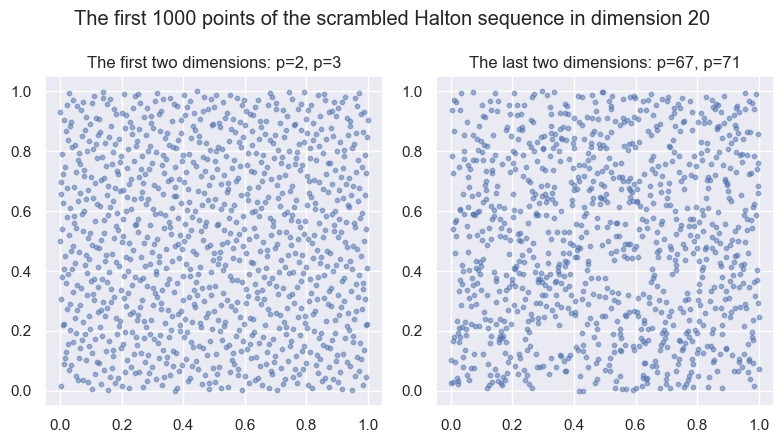

In [42]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(8, 4.5), layout='tight')
ax1.scatter(sample[:,0], sample[:,1], s=10, marker='o', alpha=0.5)
ax1.set_title("The first two dimensions: p=2, p=3")
ax2.scatter(sample[:,-2], sample[:,-1], s=10, marker='o', alpha=0.5) 
ax2.set_title("The last two dimensions: p=67, p=71")
fig.suptitle("The first 1000 points of the scrambled Halton sequence in dimension 20")
plt.show()

#### Allons voir le code utilisé dans `scipy`: `cython` inside

Si on cherche dans les sources de `scipy` on trouve à la ligne 373 du
[fichier sur
github](https://github.com/scipy/scipy/blob/de80faf9d3480b9dbb9b888568b64499e0e70c19/scipy/stats/_qmc_cy.pyx#L373)
la définition de la fonction `_cy_van_der_corput_threaded_loop`. En fait
ce n’est pas une fonction écrite en `python` mais en `cython`. Le
langage `cython` permet d’écrire des fonctions `C` qui seront compilés
et utilisables facilement en `python`. C’est une des approches pour
interfacer le `C` et le `python`.

Vous pouvez voir plus de détails sur la [page de
tutoriel](https://cython.readthedocs.io/en/stable/src/tutorial/cython_tutorial.html).

> **Note**
>
> On peut comparer les temps de simulation entre le code `cython` de
> `scipy` et notre code maison en `numpy`. Notre implémentation est plus
> efficace.
>
> ``` python
> n = int(1e6)
> halt = stats.qmc.Halton(d=5)
> %timeit -o halton(d=5, n=n)    # version optimisée en numpy
> %timeit -o halt.random(n=n)    # version scipy (cython)
> ```
>
>     17.2 ms ± 108 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
>     163 ms ± 854 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
>
>     <TimeitResult : 163 ms ± 854 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)>
>
> **A retenir:** Un compilateur peut vous faire gagner un facteur 10 ou
> 100, mais c’est aussi le cas pour un changement d’algorithme!

### Suite de Sobol

L’algorithme le plus populaire pour les suites à discrépances faible. La
génération d’une suite de Sobol est très rapide car toute l’arithmétique
se fait en base `2` (à la différence de la suite de Halton). De plus la
représentation binaire d’un entier `n` peut se faire en utilisant le
[code de Gray](https://en.wikipedia.org/wiki/Gray_code) qui permet
d’avoir la modification d’un seul bit entre 2 entiers consécutifs.

L’algorithme de Sobol dépend de paramètres à définir (un peu comme les
paramètres d’un générateur de nombres pseudo-aléatoires). Il est très
important de bien initialiser ces paramètres (les directions).

On recommande d’utiliser uniquement des algorithmes déjà codés, testés
et éprouvés! Il ne faut pas recoder son prore algorithme qui sera
peut-être invalide.

#### Utilisation de `scipy`

La classe `Sobol` du module `stats.qmc` s’utilise de la même façon que
la classe `Halton`. On peut voir que l’algorithme est très rapide. Le
warning indique qu’il vaut mieux travailler avec $n$ qui est une
puissance de 2.

In [43]:
from scipy import stats
Sob = stats.qmc.Sobol(5, scramble=False)
nbig = int(1e6)
#%timeit Sob.random(nbig)

In [44]:
n, d = 2**10, 20
sob = stats.qmc.Sobol(d=d, scramble=False)
sample = sob.random(n=n)

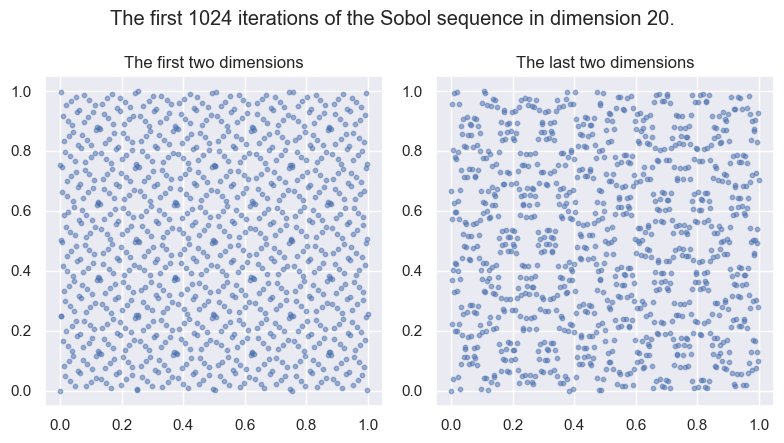

In [45]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(8, 4.5), layout='tight')
ax1.scatter(sample[:,0], sample[:,1], s=10, marker='o', alpha=0.5)
ax1.set_title("The first two dimensions")
ax2.scatter(sample[:,-2], sample[:,-1], s=10, marker='o', alpha=0.5) 
ax2.set_title("The last two dimensions")
fig.suptitle(f"The first {n} iterations of the Sobol sequence in dimension {d}.")
plt.show()

La même chose avec la version pertubée (option `scramble=True` activée
par défaut).

In [46]:
n, d = 2**10, 20
sob = stats.qmc.Sobol(d=d, scramble=True)
sample = sob.random(n=n)

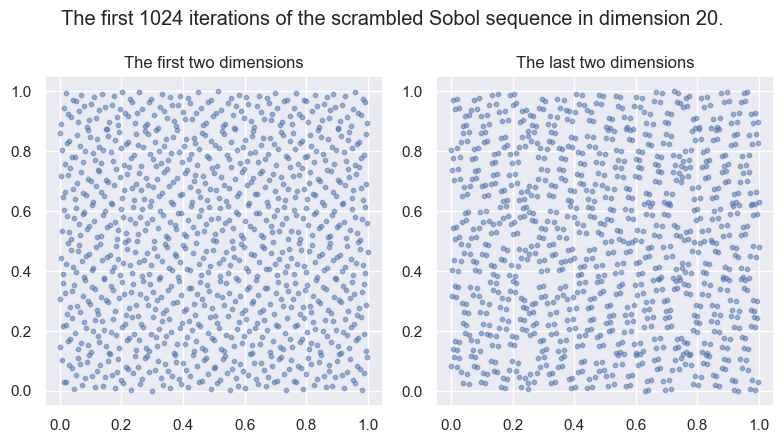

In [47]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(8, 4.5), layout='tight')
ax1.scatter(sample[:,0], sample[:,1], s=10, marker='o', alpha=0.5)
ax1.set_title("The first two dimensions")
ax2.scatter(sample[:,-2], sample[:,-1], s=10, marker='o', alpha=0.5) 
ax2.set_title("The last two dimensions")
fig.suptitle(f"The first {n} iterations of the scrambled Sobol sequence in dimension {d}.")
plt.show()

## Intégration code C++ via `pybind11`

On a vu précédemment qu’il est possible d’écrire un code très proche du
`python` qui sera compilé pour de meilleures performances: c’est le
langage `cython`.

Une autre approche vient du projet `pybind11`. Imaginons qu’on dispose
d’un code `C++`, une librairie écrite et optimisée en `C++`. Le projet
`pybind11` permet d’écrire assez facilement un module `python` qui
permet d’accéder à ce code `C++`.

Nous allons illustrer l’utilisation de `pybind11` pour interfacer
(utiliser) la fonction `sobol` de la Gnu Scientific Library (code `C`
orienté objet) dans un code `python`. Voici les différentes étapes:

-   Comprendre la documentation de la section Quasi-Monte Carlo de la
    `GSL`
-   Encapsuler ce code `C` dans un code objet `C++` (pas obligatoire,
    mais permet de faire des rappels de `C++`)
-   Utiliser `pybind11` pour accéder à ce code `C++`

> **Note**
>
> Tout le code (que l’on va détailler) se trouve dans le répertoire
> `sobol_module`:
>
>     sobol_module
>     ├── CMakeLists.txt
>     ├── include
>     │   └── sobol.hpp
>     ├── python
>     │   └── module.cpp
>     └── src
>         └── test.cpp
>
> -   le fichier `include/sobol.hpp` contient le code de la “librairie”
>     `C++`
> -   le fichier `src/test.cpp` contient un code `C++` pour tester la
>     “librairie” `C++`
> -   le fichier `python/module.cpp` contient le code `C++` pour
>     interfacer le `C++` en `python` via `pybind11`.

### Création d’une interface `C++`

Voici un code possible pour créer une classe `sobol` qui **encapsule**
le code `C` de la `GSL`. On détaille le rôle des constructeurs, du
destructeur, des opérateurs d’affectation et des 2 méthodes:

-   la surcharge de l’opérateur fonctionnel `operator()`
-   la méthode `get`

``` cpp
#pragma once

#include <vector>
#include <gsl/gsl_qrng.h>

class sobol {
    public:
        sobol(int dimension) : dimension(dimension) {
            q = gsl_qrng_alloc(gsl_qrng_sobol, dimension); }
        sobol(sobol const & o) : dimension(o.dimension) {
            q = gsl_qrng_clone(o.q); }
        sobol(sobol && o) = default;
        sobol & operator=(sobol const & o);
        sobol & operator=(sobol && o) = default;
        ~sobol() { gsl_qrng_free(q); }

        auto operator()();
        void get(double * data) { gsl_qrng_get(q, data); }

    private:
        int dimension;
        gsl_qrng * q;
};

sobol & sobol::operator=(sobol const & o) {
    if (this != &o) {
        dimension = o.dimension;
        gsl_qrng_memcpy(q, o.q);
    }
    return *this;
};

auto sobol::operator()() {
    std::vector<double> result(this->dimension);
    gsl_qrng_get(q, &(*result.begin()));
    return result;
};
```

Voici un exemple d’utilisation de cette classe. Le fichier
`src/test.cpp` doit être compilé sans erreur.

``` cpp
#include <iostream>
#include "sobol.hpp"

using namespace std;
int main() {
    int d = 2;
    sobol S(d);

    for (int n = 0; n < 1e2; ++n) {
        auto xi_n = S();
        cout << n << ":\t" << xi_n[0] << "\t" << xi_n[1] << endl;
    }

    return 0;
}
```

Pour compiler ce code (via `cmake` et `make`) on peut utiliser le
fichier `CMakeLists.txt` suivant:

``` cmake
cmake_minimum_required(VERSION 3.9)
set(CMAKE_VERBOSE_MAKEFILE ON)

project(sobol_module LANGUAGES CXX)

set(CMAKE_CXX_STANDARD 17)
set(CMAKE_CXX_STANDARD_REQUIRED ON)
set(CMAKE_CXX_EXTENSIONS OFF)
set(CMAKE_CXX_FLAGS "${CMAKE_CXX_FLAGS} -Wall -Os -ffast-math")
set(CMAKE_MODULE_LINKER_FLAGS "-Wl,-w")

include_directories("${CMAKE_SOURCE_DIR}/include")

find_package(GSL REQUIRED)
include_directories(${GSL_INCLUDE_DIRS} ${GSLCBLAS_INCLUDE_DIRS})
set(LIBS ${LIBS} ${GSL_LIBRARIES} ${GSLCBLAS_LIBRARIES})

add_executable(sobol_test src/test.cpp)
target_link_libraries(sobol_test ${LIBS})
```

L’outil [cmake](https://cmake.org/) est utilisé pour produire un fichier
`Makefile` compatible avec l’OS et l’environnement installé. Le fichier
`Makefile` étant produit, on utiliser l’outil `make` pour effectivement
compiler le code (avec les bonnes librairies). Les étapes usuelles sont:

``` {bash}
mkdir build    # on crée le répertoire vide (contenu de la compilation)
cd build       
cmake ..       # on appelle cmake sur `CMakeLists.txt` du répertoire père
make           # on appelle make pour la compilation 
```

Pour garder que les sources, on détruit le répertoire `build` (dont le
contenu est propre à chaque environnement/ordinateur).

### Intégration via `pybind11`

On consulte la [documentation de ce
module](https://pybind11.readthedocs.io/en/stable/basics.html). Un
premier exemple est donné ci-dessous:

``` {cpp}
#include <pybind11/pybind11.h>

int add(int i, int j) {
    return i + j;
}

PYBIND11_MODULE(example, m) {
    m.doc() = "pybind11 example plugin"; // optional module docstring

    m.def("add", &add, "A function which adds two numbers",
      py::arg("i"), py::arg("j"));
}
```

Le code `PYBIND11_MODULE` est une macro `C/C++` qui permet la création
d’un module `python` dont le nom est `example` et le contenu est `m`
(`m` est un objet dont on va définir des méthodes). Dans l’exemple
précédent `m.doc()` permet de définir une documentation et `m.def`
ajoute dans le module python une fonction `add` dont le code de la
fonction `C++` se trouve à l’adresse `&add`.

Ici on va utiliser un code un peu plus riche et on fait appel à
`pybind11/numpy.h` pour manipuler des array numpy dans notre code `C++`.
Pour plus d’information voir la
[documentation](https://pybind11.readthedocs.io/en/stable/advanced/pycpp/numpy.html#vectorizing-functions).

Le module créé s’appelle `sobol_module`. Dans ce module se trouve une
fonction `sobol` et le code est donné par une *lambda function* qui
prend 2 arguments `n` et `dim` et renvoie un array de dimension
`(n, dim)` qui contient les `n` premiers termes de la suite de Sobol en
dimension `dim`.

``` cpp
#include <pybind11/pybind11.h>
#include <pybind11/numpy.h>
#include <pybind11/stl.h>
#include "sobol.hpp"

namespace py = pybind11;

PYBIND11_MODULE(sobol_module, m) {
    m.doc() = "Sobol GSL module integrated via pybind11"; 
    m.def("sobol", [](int n, int dim) {
        sobol S(dim);
        auto result = py::array_t<double>(n * dim).reshape({ n, dim });
        auto buf = result.request();
        double * ptr = static_cast<double*>(buf.ptr);
        for (int k = 0; k < n; ++k) {
            S.get(ptr);
            ptr += dim;
        }
        return result;
    });
}
```

> **Note**
>
> Pour la compilation il suffit de modifier le fichier `CMakeLists` et
> d’ajouter les lignes suivantes (on suppose que `pybind11` est bien
> installé).
>
> ``` cmake
> find_package(Python 3.11 EXACT COMPONENTS Interpreter Development)
> find_package(pybind11 CONFIG REQUIRED)
> pybind11_add_module(sobol_module python/module.cpp) 
> target_link_libraries(sobol_module PUBLIC GSL::gsl GSL::gslcblas)
> ```

Dans le répertoire `sobol_module` se trouve maintenant le
sous-répertoire `build` qui contient
`sobol_module.cpython-311-darwin.so` une librairie (module) qui peut
être chargé pour utilisé la fonction `sobol`. Un appel possible est le
suivant

In [48]:
%cd sobol_module/build/
from sobol_module import sobol 

[WinError 3] The system cannot find the path specified: 'sobol_module/build/'
c:\Users\lione\OneDrive\Documents\PROJET_EL_KAROUI\EL_KAROUI\NUMERICAL_METHOD\TPs\tp7_qmc


ModuleNotFoundError: No module named 'sobol_module'

In [ ]:
sobol(20, 5)

array([[0.5    , 0.5    , 0.5    , 0.5    , 0.5    ],
       [0.75   , 0.25   , 0.75   , 0.25   , 0.75   ],
       [0.25   , 0.75   , 0.25   , 0.75   , 0.25   ],
       [0.375  , 0.375  , 0.625  , 0.125  , 0.875  ],
       [0.875  , 0.875  , 0.125  , 0.625  , 0.375  ],
       [0.625  , 0.125  , 0.375  , 0.375  , 0.125  ],
       [0.125  , 0.625  , 0.875  , 0.875  , 0.625  ],
       [0.1875 , 0.3125 , 0.3125 , 0.6875 , 0.5625 ],
       [0.6875 , 0.8125 , 0.8125 , 0.1875 , 0.0625 ],
       [0.9375 , 0.0625 , 0.5625 , 0.9375 , 0.3125 ],
       [0.4375 , 0.5625 , 0.0625 , 0.4375 , 0.8125 ],
       [0.3125 , 0.1875 , 0.9375 , 0.5625 , 0.4375 ],
       [0.8125 , 0.6875 , 0.4375 , 0.0625 , 0.9375 ],
       [0.5625 , 0.4375 , 0.1875 , 0.8125 , 0.6875 ],
       [0.0625 , 0.9375 , 0.6875 , 0.3125 , 0.1875 ],
       [0.09375, 0.46875, 0.84375, 0.40625, 0.28125],
       [0.59375, 0.96875, 0.34375, 0.90625, 0.78125],
       [0.84375, 0.21875, 0.09375, 0.15625, 0.53125],
       [0.34375, 0.71875, 0.

In [ ]:
%timeit sobol(1000000, 5)

3.13 ms ± 31.9 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


> **Warning**
>
> Pour aller plus loin, il est possible d’intégrer une classe `C++` en
> `python` via `pybind11`. Lire la
> [documentation](https://pybind11.readthedocs.io/en/stable/classes.html)
> et appliquer à la classe `sobol` du fichier `include/sobol.hpp`.

## Application aux options basket

On adapte le code de la séance précédente pour faire un code QMC et
comparer avec le code MC.

In [ ]:
%cd ../..
%cd ../tp_basket_pytorch
%run tp_basket_pytorch_sujet.ipynb

/Users/lemaire/cloud/dropsu/cours/dufe/tp_qmc
/Users/lemaire/cloud/dropsu/cours/dufe/tp_basket_pytorch


In [ ]:
def monte_carlo_by_steps(sampling_function: callable, 
                         steps: np.ndarray,
                         proba: float = 0.95) -> dict:
    """
    Effectue une estimation de Monte Carlo par étapes successives et calcule 
    les intervalles de confiance pour la moyenne à chaque étape.

    Args:
    - sampling_function (callable): Fonction qui génère des échantillons.
    - steps (np.ndarray): Tableau des étapes successives.
    - proba (float): Niveau de confiance pour les intervalles de confiance.

    Returns:
    - dict: Un dictionnaire contenant les moyennes, les variances et 
    les intervalles de confiance pour chaque étape.
    """
    alpha = 1 - proba
    quantile = sps.norm.ppf(1 - alpha / 2)

    means = np.empty(len(steps))
    variances = np.empty(len(steps)) 
    prev_step = 0
    
    sum_, sum2_ = 0.0, 0.0
    for k, step in enumerate(steps):   
        samples = sampling_function(steps[k] - prev_step)
        sum_ += samples.sum()
        sum2_ += (samples**2).sum()
        
        means[k] = sum_ / step
        variances[k] = step / (step-1) * (sum2_ / step - means[k]**2)
        prev_step = steps[k]

    ci_sizes = 2 * quantile * np.sqrt(variances / steps)
    return {
        "steps": steps,
        "means": means,
        "variances": variances,
        "lowers": means - ci_sizes,
        "uppers": means + ci_sizes,
    }

In [ ]:
K = 100
step_size = 100
steps = step_size + np.arange(0, 500000, step_size)
r_mc = monte_carlo_by_steps(
    lambda size: sampling_payoffs(K, size, bs, rng), 
    steps)

> **Note**
>
> Il suffit ici de modifier la fonction `sampling_payoffs` en remplaçant
> l’appel de
>
> ``` {default}
> rng.standard_normal((size, bs["d"]))
> ```
>
> par
>
> ``` {default}
> stats.norm.ppf(qmc_algo.random(size))
> ```
>
> où `qmc_algo` code une suite à discrépance faible sur $(0,1)^d$.

In [ ]:
def qsampling_payoffs(K, size, bs, qmc_algo):
    Gn = stats.norm.ppf(qmc_algo.random(size))
    samples = phi(bs, Gn)
    payoffs = np.maximum(np.mean(samples, axis=1)-K, 0.) 
    return bs["actualization"] * payoffs

In [ ]:
qmc_algos = {
    "halton": stats.qmc.Halton(d=d, scramble=False).fast_forward(1), 
    "halton_scrambled": stats.qmc.Halton(d=d, scramble=True).fast_forward(1), 
    "sobol": stats.qmc.Sobol(d=d, scramble=False).fast_forward(1),
    "sobol_scrambled": stats.qmc.Sobol(d=d, scramble=True).fast_forward(1)
}

> **Warning**
>
> On appelle la méthode `fast_forward(k)` pour démarrer à partir de
> l’itération $k$. Ici on part à partir de l’itération $k=1$ pour
> supprimer le point $0 \in [0,1]^d$ qui pose problème lors de l’appel
> de `stats.norm.ppf` !
>
> En pratique on remarque qu’on peut avoir une convergence plus rapide
> pour Halton en supprimant les premières itérations.

In [ ]:
r_qmc = { 
    name: monte_carlo_by_steps(
        lambda size: qsampling_payoffs(K, size, bs, algo),
        steps)
    for name, algo in qmc_algos.items() 
}

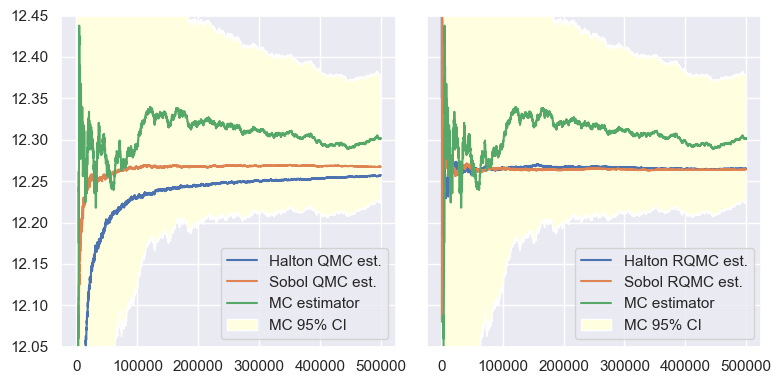

In [ ]:
fig, (ax1, ax2) = plt.subplots(figsize=(8, 4), ncols=2, nrows=1, 
                               sharey=True, layout='tight')

ax1.plot(steps, r_qmc["halton"]["means"], label="Halton QMC est.")
ax1.plot(steps, r_qmc["sobol"]["means"], label="Sobol QMC est.")
ax2.plot(steps, r_qmc["halton_scrambled"]["means"], label="Halton RQMC est.")
ax2.plot(steps, r_qmc["sobol_scrambled"]["means"], label="Sobol RQMC est.")
for ax in (ax1, ax2): 
    ax.plot(steps, r_mc["means"], label="MC estimator")
    ax.fill_between(steps, r_mc["lowers"], r_mc["uppers"], 
                    facecolor='lightyellow', label="MC 95% CI")
    ax.set_ylim([12.05, 12.45])
    ax.legend(loc='lower right')
plt.show()

### Avec variable de contrôle

In [ ]:
def qsampling_payoffs_control_variate(K, size, bs, qmc_algo):
    Gn = stats.norm.ppf(qmc_algo.random(size))
    payoffs_X = np.maximum(np.mean(phi(bs, Gn), axis=1) - K, 0) 
    payoffs_Y = payoffs_control(bs, K, Gn)
    payoffs = payoffs_X - payoffs_Y
    return bs["actualization"] * payoffs

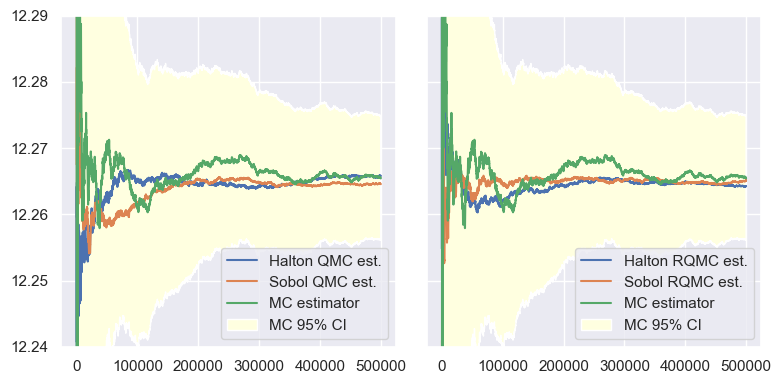

In [ ]:
r_mc = monte_carlo_by_steps(
    lambda size: sampling_payoffs_control_variate(K, size, bs, rng), 
    steps)
r_qmc = { 
    name: monte_carlo_by_steps(
        lambda size: qsampling_payoffs_control_variate(K, size, bs, algo),
        steps)
    for name, algo in qmc_algos.items() 
}
fig, (ax1, ax2) = plt.subplots(figsize=(8, 4), ncols=2, nrows=1, 
                               sharey=True, layout='tight')

ax1.plot(steps, r_qmc["halton"]["means"], label="Halton QMC est.")
ax1.plot(steps, r_qmc["sobol"]["means"], label="Sobol QMC est.")
ax2.plot(steps, r_qmc["halton_scrambled"]["means"], label="Halton RQMC est.")
ax2.plot(steps, r_qmc["sobol_scrambled"]["means"], label="Sobol RQMC est.")
for ax in (ax1, ax2): 
    ax.plot(steps, r_mc["means"], label="MC estimator")
    ax.fill_between(steps, r_mc["lowers"], r_mc["uppers"], 
                    facecolor='lightyellow', label="MC 95% CI")
    ax.set_ylim([12.24, 12.29])
    ax.legend(loc='lower right')
plt.show()